# Decoder training example

## Importing and preparation

In [1]:
import sys
import os
from pathlib import Path
from omegaconf import OmegaConf
import pandas as pd
import torch

project_root = Path().absolute().parent
sys.path.append(str(project_root))

### Path preparation

In [2]:
%cd ..

/Users/alex/Edu/Bioinformatics_institute/Project/Vlasova/gitlab


/Users/alex/miniconda3/envs/tcreppred_sil2/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
output_dir = 'decoder_exp_onehot'
weights_suf = 'weights'
report_suf = 'report'
embds_suf = 'embds'

### Constants

In [4]:
embd_type = 'onehot'

In [5]:
from tcrenc.tcrenc_run import main as tcrenc_run_main
from tcrenc.tcrenc_train import main as tcrenc_train_main
from tcrenc.tcrenc_validate import main as tcrenc_validate_main

/Users/alex/miniconda3/envs/tcreppred_sil2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Train decoder for onehot sequence representation

General pipeline:
```
1. Prepare data -> 2. Train decoder -> 3. Update weights in autoencoder model -> 4.Validate on VDJdb 
```

### 1.Prepare input data
We will use output of tcrenc-run of pretrained onehot model

### 2.Train decoder

In [6]:
script_name = 'tcrenc_train'

val_args = {
  "--input":'examples/data/embeddings_cdr3_onehot.csv',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, weights_suf),
  '--split': '0.8'
}
logic_args = [
    "--decoder_train",
    "--weights_save"
    # '--cdr'
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [7]:
tcrenc_train_main(sys.argv)

Training model for cdr3 ...
[0/200] Train Loss: 2.6982 | Test Loss: 1.7284
[20/200] Train Loss: 0.0393 | Test Loss: 0.0430
[40/200] Train Loss: 0.0108 | Test Loss: 0.0168
[60/200] Train Loss: 0.0058 | Test Loss: 0.0125
[80/200] Train Loss: 0.0039 | Test Loss: 0.0111
[100/200] Train Loss: 0.0029 | Test Loss: 0.0105
[120/200] Train Loss: 0.0023 | Test Loss: 0.0102
[140/200] Train Loss: 0.0019 | Test Loss: 0.0101
[160/200] Train Loss: 0.0016 | Test Loss: 0.0101
[180/200] Train Loss: 0.0014 | Test Loss: 0.0102
[199/200] Train Loss: 0.0012 | Test Loss: 0.0103
Train for cdr3 finished


### 3. Update weights in Autoencoder_onehot model

This part is important for adapting the new weights to the autoencoder model

In [8]:
path_new = os.path.join(output_dir, weights_suf,'weights_onehot_cdr3.pth')
new_w_dict = torch.load(path_new, map_location=torch.device('cpu'))
path_old = 'tcrenc/models/autoencoder_onehot/weights/cdr3_model_final_restructed.pth'
old_w_dict = torch.load(path_old, map_location=torch.device('cpu'))

decoder_w_names = []
with torch.no_grad():

    for key, value in new_w_dict.items():
        if 'decoder' in key:
            decoder_w_names.append(key)

    print(decoder_w_names)

    for key, value in old_w_dict.items():
        if key in decoder_w_names:
            old_w_dict[key] = new_w_dict[key]


path_out = os.path.join(output_dir, weights_suf,'weights_autoencoder_new_decodcer_onehot_cdr3.pth')
torch.save(old_w_dict, path_out)

['decoder.0.weight', 'decoder.0.bias']


In [9]:
with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)

# Update
special_config['validate']['WEIGHTS_CDR3'] = path_out

with open('./tcrenc/configs/config_onehot.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

### 4.Model with new decoder validation on VDJdb

In [10]:
script_name = 'tcrenc_validate'

val_args = {
  "--input":'VDJdb',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, report_suf),
}
logic_args = [
    '--cdr'
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

Average reconstruction error of cdr3 sequences on sample: 0.0039
All files saved!


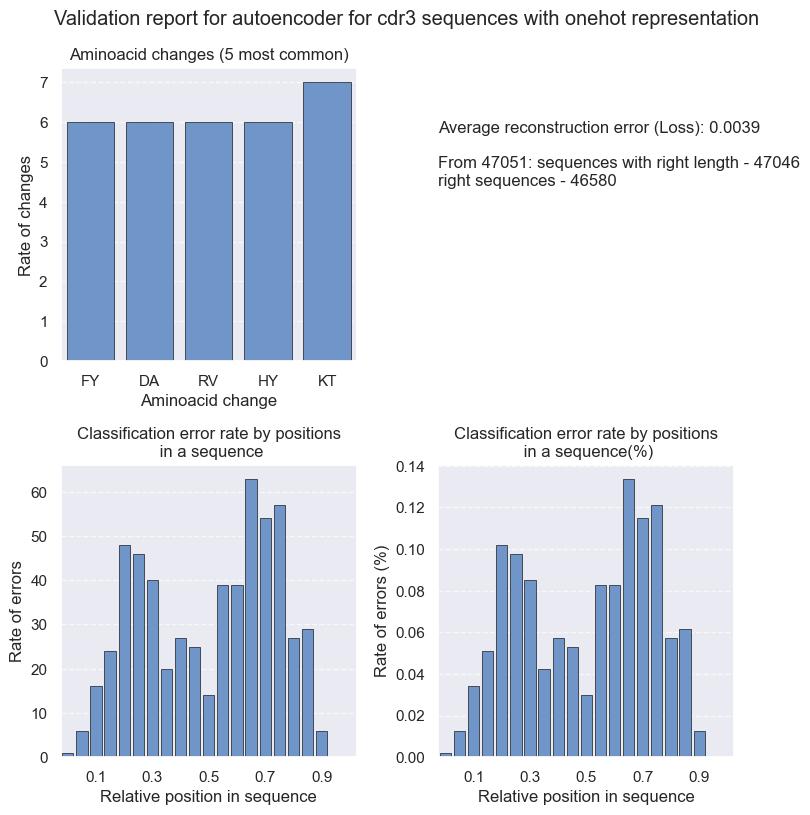

In [11]:
tcrenc_validate_main(sys.argv)

If results are not suitable go back to pretrained model.

In [12]:
with open('./tcrenc/configs/config_onehot.yaml') as f:
    special_config = OmegaConf.load(f)

# Update
special_config['validate']['WEIGHTS_CDR3'] = 'tcrenc/models/autoencoder_onehot/weights/cdr3_model_final_restructed.pth'

with open('./tcrenc/configs/config_onehot.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

### Re-validate

In [13]:
script_name = 'tcrenc_validate'

val_args = {
  "--input":'VDJdb',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, report_suf),
}
logic_args = [
    '--cdr'
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

Average reconstruction error of cdr3 sequences on sample: 0.0039
All files saved!


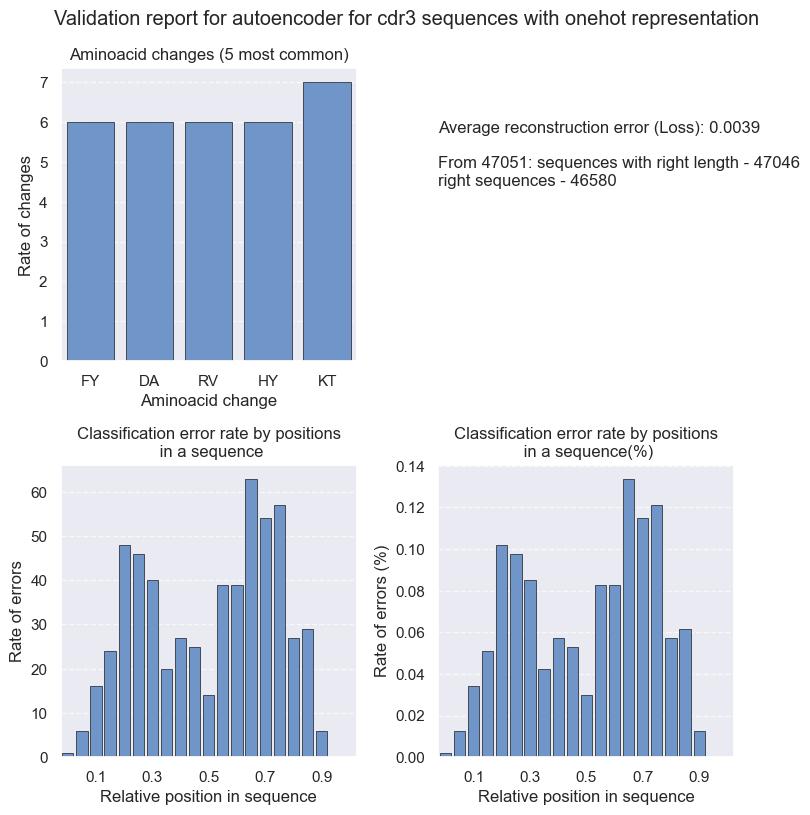

In [14]:
tcrenc_validate_main(sys.argv)